Setup and Imports

In [1]:
!pip install -q rank-bm25 sentence-transformers

import pandas as pd
import numpy as np
import re
from pathlib import Path
from tqdm import tqdm
import ast
import json

from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer, util
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_colwidth', 80)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

BASE = Path("/content/drive/MyDrive/CS685/linkedin")
ESCO_PATH = "/content/drive/MyDrive/CS685/esco/skills_en.csv"

TEST_PREDS = BASE / "distilbert_runA_test_wordlevel_preds.csv"
TEST_DATA = BASE / "ner_data_v3/bio_test.csv"

Mounted at /content/drive


Load and Prepare ESCO Taxonomy

In [3]:
def parse_alt_labels(raw):
    """Parse ESCO alternative labels (newline-separated)."""
    if pd.isna(raw):
        return []
    text = str(raw)
    items = []
    for line in text.splitlines():
        line = line.strip()
        if line:
            items.append(line)
    # Deduplicate
    seen = set()
    out = []
    for x in items:
        x2 = x.strip().lower()
        if x2 and x2 not in seen:
            seen.add(x2)
            out.append(x)
    return out

# Load ESCO
esco = pd.read_csv(ESCO_PATH)
print(f"ESCO skills: {len(esco)}")
esco.head(3)

ESCO skills: 13939


,conceptType,conceptUri,skillType,reuseLevel,preferredLabel,altLabels,hiddenLabels,status,modifiedDate,scopeNote,definition,inScheme,description
0,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/0005c151-5b5a-4a66-8aac-60e734beb1ab,skill/competence,sector-specific,manage musical staff,manage staff of music\ncoordinate duties of musical staff\nmanage music staf...,NaN,released,2023-11-30T15:53:37.136Z,NaN,NaN,"http://data.europa.eu/esco/concept-scheme/skills,\nhttp://data.europa.eu/esc...","Assign and manage staff tasks in areas such as scoring, arranging, copying m..."
1,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/00064735-8fad-454b-90c7-ed858cc993f2,skill/competence,occupation-specific,supervise correctional procedures,oversee prison procedures\nmanage correctional procedures\nmonitor correctio...,NaN,released,2023-11-30T15:04:00.689Z,NaN,NaN,"http://data.europa.eu/esco/concept-scheme/member-skills,\nhttp://data.europa...",Supervise the operations of a correctional facility or other correctional pr...
2,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/000709ed-2be5-4193-b056-45a97698d828,skill/competence,sector-specific,apply anti-oppressive practices,apply non-oppressive practices\napply an anti-oppressive practice\nmake use ...,NaN,released,2023-11-28T10:45:53.54Z,NaN,NaN,"http://data.europa.eu/esco/concept-scheme/skills,\nhttp://data.europa.eu/esc...","Identify oppression in societies, economies, cultures, and groups, acting as..."


In [4]:
# Build skill dictionary with all variants
esco['alt_list'] = esco['altLabels'].apply(parse_alt_labels)

skill_records = []
for _, row in esco.iterrows():
    skill_id = row['conceptUri']
    preferred = str(row['preferredLabel']).strip()

    # All variants: preferred + alternatives
    variants = [preferred] + row['alt_list']

    for variant in variants:
        variant = variant.strip()
        if variant and len(variant) > 1:
            skill_records.append({
                'skill_id': skill_id,
                'preferred_label': preferred,
                'variant': variant,
                'variant_lower': variant.lower()
            })

skill_df = pd.DataFrame(skill_records)
skill_df = skill_df.drop_duplicates(subset=['variant_lower'])
print(f"Total skill variants: {len(skill_df)}")
skill_df.head()

Total skill variants: 99186


,skill_id,preferred_label,variant,variant_lower
0,http://data.europa.eu/esco/skill/0005c151-5b5a-4a66-8aac-60e734beb1ab,manage musical staff,manage musical staff,manage musical staff
1,http://data.europa.eu/esco/skill/0005c151-5b5a-4a66-8aac-60e734beb1ab,manage musical staff,manage staff of music,manage staff of music
2,http://data.europa.eu/esco/skill/0005c151-5b5a-4a66-8aac-60e734beb1ab,manage musical staff,coordinate duties of musical staff,coordinate duties of musical staff
3,http://data.europa.eu/esco/skill/0005c151-5b5a-4a66-8aac-60e734beb1ab,manage musical staff,manage music staff,manage music staff
4,http://data.europa.eu/esco/skill/0005c151-5b5a-4a66-8aac-60e734beb1ab,manage musical staff,direct musical staff,direct musical staff


Build BM25 Index

In [5]:
def tokenize_for_bm25(text):
    """Simple tokenization for BM25."""
    text = text.lower()
    # Keep alphanumeric and some special chars
    text = re.sub(r'[^a-z0-9\s+#/.-]', ' ', text)
    tokens = text.split()
    return [t for t in tokens if t]

# Tokenize all ESCO variants
print("Tokenizing ESCO variants for BM25...")
esco_texts = skill_df['variant'].tolist()
tokenized_esco = [tokenize_for_bm25(text) for text in tqdm(esco_texts)]

# Build BM25 index
print("Building BM25 index...")
bm25 = BM25Okapi(tokenized_esco)
print("BM25 index ready!")

Tokenizing ESCO variants for BM25...


100%|██████████| 99186/99186 [00:00<00:00, 223221.20it/s]


Building BM25 index...
BM25 index ready!


Load Sentence Transformer for Re-ranking

In [6]:
# Load cross-encoder for semantic similarity
print("Loading sentence transformer...")
model = SentenceTransformer('all-MiniLM-L6-v2')
print("Model loaded!")

Loading sentence transformer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded!


Load Test Data and Predictions

In [7]:
def parse_list_col(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    return ast.literal_eval(x)

# Load test data with sentences
test_df = pd.read_csv(TEST_DATA)
test_df['tokens'] = test_df['tokens'].apply(parse_list_col)
test_df['tags'] = test_df['tags'].apply(parse_list_col)
test_df['gold_spans'] = test_df['gold_spans'].apply(parse_list_col)

# Load predictions
preds_df = pd.read_csv(TEST_PREDS)
preds_df['tokens'] = preds_df['tokens'].apply(parse_list_col)
preds_df['gold_tags'] = preds_df['gold_tags'].apply(parse_list_col)
preds_df['pred_tags'] = preds_df['pred_tags'].apply(parse_list_col)

print(f"Test samples: {len(test_df)}")
print(f"Predictions: {len(preds_df)}")

Test samples: 105
Predictions: 105


In [8]:
# Extract Predicted Spans
def bio_to_spans(tokens, tags):
    """Convert BIO tags to skill spans."""
    spans = []
    current = []

    for tok, tag in zip(tokens, tags):
        if tag == "B-SKILL":
            if current:
                spans.append(" ".join(current))
            current = [tok]
        elif tag == "I-SKILL":
            if current:
                current.append(tok)
            else:
                current = [tok]
        else:  # O
            if current:
                spans.append(" ".join(current))
                current = []

    if current:
        spans.append(" ".join(current))

    return spans

# Extract predicted spans
preds_df['pred_spans'] = preds_df.apply(
    lambda r: bio_to_spans(r['tokens'], r['pred_tags']), axis=1
)

Normalization Pipeline

In [9]:
def normalize_skill_v1(mention, context_sentence, k=10, threshold=0.5):

    # Step 1: BM25 retrieval
    query_tokens = tokenize_for_bm25(mention)
    scores = bm25.get_scores(query_tokens)
    top_k_idx = np.argsort(scores)[-k:][::-1]
    candidates = skill_df.iloc[top_k_idx]

    # Step 2: Exact match check
    mention_lower = mention.lower().strip()
    for idx in top_k_idx:
        if skill_df.iloc[idx]['variant_lower'] == mention_lower:
            return {
                'skill_id': skill_df.iloc[idx]['skill_id'],
                'preferred_label': skill_df.iloc[idx]['preferred_label'],
                'matched_variant': skill_df.iloc[idx]['variant'],
                'score': 1.0,
                'method': 'exact_match'
            }

    # Step 3: Semantic re-ranking with context
    query_text = f"{mention} [SEP] {context_sentence}"
    candidate_texts = candidates['variant'].tolist()

    query_embedding = model.encode(query_text, convert_to_tensor=True)
    candidate_embeddings = model.encode(candidate_texts, convert_to_tensor=True)
    similarities = util.cos_sim(query_embedding, candidate_embeddings)[0]

    best_idx = similarities.argmax().item()
    best_score = similarities[best_idx].item()

    if best_score >= threshold:
        best_candidate = candidates.iloc[best_idx]
        return {
            'skill_id': best_candidate['skill_id'],
            'preferred_label': best_candidate['preferred_label'],
            'matched_variant': best_candidate['variant'],
            'score': float(best_score),
            'method': 'semantic'
        }

    return None

Run V1 Normalization on Predictions

In [10]:
normalization_results_v1 = []

print("="*70)
print("Running V1 normalization (k=10, threshold=0.5)...")
print("="*70)

for idx, row in tqdm(preds_df.iterrows(), total=len(preds_df)):
    sentence = " ".join(row['tokens'])
    pred_spans = row['pred_spans']

    for span in pred_spans:
        result = normalize_skill_v1(span, sentence, k=10, threshold=0.5)

        normalization_results_v1.append({
            'idx': idx,
            'sentence': sentence,
            'mention': span,
            'skill_id': result['skill_id'] if result else None,
            'preferred_label': result['preferred_label'] if result else None,
            'matched_variant': result['matched_variant'] if result else None,
            'score': result['score'] if result else 0.0,
            'method': result['method'] if result else 'NIL',
            'is_nil': result is None
        })

norm_df_v1 = pd.DataFrame(normalization_results_v1)

# V1 Statistics
stats_v1 = {
    'version': 'v1',
    'k_candidates': 10,
    'threshold': 0.5,
    'total_mentions': int(len(norm_df_v1)),
    'mapped': int((~norm_df_v1['is_nil']).sum()),
    'nil': int(norm_df_v1['is_nil'].sum()),
    'mapped_pct': float((~norm_df_v1['is_nil']).mean() * 100),
    'exact_matches': int((norm_df_v1['method'] == 'exact_match').sum()),
    'semantic_matches': int((norm_df_v1['method'] == 'semantic').sum()),
    'mean_score': float(norm_df_v1[~norm_df_v1['is_nil']]['score'].mean()) if len(norm_df_v1[~norm_df_v1['is_nil']]) > 0 else 0.0,
}

print(f"\n{'='*70}")
print("V1 RESULTS")
print(f"{'='*70}")
print(f"Mapped: {stats_v1['mapped']} ({stats_v1['mapped_pct']:.1f}%)")
print(f"NIL: {stats_v1['nil']} ({100-stats_v1['mapped_pct']:.1f}%)")
print(f"\nMethod breakdown:")
print(norm_df_v1['method'].value_counts())
print(f"\nMean score (mapped): {stats_v1['mean_score']:.3f}")

Running V1 normalization (k=10, threshold=0.5)...


100%|██████████| 105/105 [00:10<00:00,  9.60it/s]


V1 RESULTS
Mapped: 91 (46.2%)
NIL: 106 (53.8%)

Method breakdown:
method
NIL            106
semantic        55
exact_match     36
Name: count, dtype: int64

Mean score (mapped): 0.750


Normalization V2

In [11]:
def normalize_skill_v2(mention, context_sentence, k=20, threshold=0.55):

    # Step 1: BM25 retrieval with MORE candidates
    query_tokens = tokenize_for_bm25(mention)
    scores = bm25.get_scores(query_tokens)
    top_k_idx = np.argsort(scores)[-k:][::-1]
    candidates = skill_df.iloc[top_k_idx]

    # Step 2: Exact match check
    mention_lower = mention.lower().strip()
    for idx in top_k_idx:
        if skill_df.iloc[idx]['variant_lower'] == mention_lower:
            return {
                'skill_id': skill_df.iloc[idx]['skill_id'],
                'preferred_label': skill_df.iloc[idx]['preferred_label'],
                'matched_variant': skill_df.iloc[idx]['variant'],
                'score': 1.0,
                'method': 'exact_match'
            }

    # Step 2.5: Substring match
    for idx in top_k_idx:
        variant_lower = skill_df.iloc[idx]['variant_lower']
        if mention_lower in variant_lower or variant_lower in mention_lower:
            if len(mention_lower) > 3 and len(variant_lower) > 3:
                return {
                    'skill_id': skill_df.iloc[idx]['skill_id'],
                    'preferred_label': skill_df.iloc[idx]['preferred_label'],
                    'matched_variant': skill_df.iloc[idx]['variant'],
                    'score': 0.95,
                    'method': 'substring_match'
                }

    # Step 3: Semantic re-ranking (simpler query, lower threshold)
    query_text = mention
    candidate_texts = candidates['variant'].tolist()

    query_embedding = model.encode(query_text, convert_to_tensor=True)
    candidate_embeddings = model.encode(candidate_texts, convert_to_tensor=True)
    similarities = util.cos_sim(query_embedding, candidate_embeddings)[0]

    best_idx = similarities.argmax().item()
    best_score = similarities[best_idx].item()

    if best_score >= threshold:
        best_candidate = candidates.iloc[best_idx]
        return {
            'skill_id': best_candidate['skill_id'],
            'preferred_label': best_candidate['preferred_label'],
            'matched_variant': best_candidate['variant'],
            'score': float(best_score),
            'method': 'semantic'
        }

    return None

Run V2 Normalization on Predictions

In [12]:
normalization_results_v2 = []

print("="*70)
print("Running V2 normalization (k=20, threshold=0.50)...")
print("="*70)

for idx, row in tqdm(preds_df.iterrows(), total=len(preds_df)):
    sentence = " ".join(row['tokens'])
    pred_spans = row['pred_spans']

    for span in pred_spans:
        result = normalize_skill_v2(span, sentence, k=20, threshold=0.50)

        normalization_results_v2.append({
            'idx': idx,
            'sentence': sentence,
            'mention': span,
            'skill_id': result['skill_id'] if result else None,
            'preferred_label': result['preferred_label'] if result else None,
            'matched_variant': result['matched_variant'] if result else None,
            'score': result['score'] if result else 0.0,
            'method': result['method'] if result else 'NIL',
            'is_nil': result is None
        })

norm_df_v2 = pd.DataFrame(normalization_results_v2)

# V2 Statistics
stats_v2 = {
    'version': 'v2',
    'k_candidates': 20,
    'threshold': 0.50,
    'total_mentions': int(len(norm_df_v2)),
    'mapped': int((~norm_df_v2['is_nil']).sum()),
    'nil': int(norm_df_v2['is_nil'].sum()),
    'mapped_pct': float((~norm_df_v2['is_nil']).mean() * 100),
    'exact_matches': int((norm_df_v2['method'] == 'exact_match').sum()),
    'substring_matches': int((norm_df_v2['method'] == 'substring_match').sum()),
    'semantic_matches': int((norm_df_v2['method'] == 'semantic').sum()),
    'mean_score': float(norm_df_v2[~norm_df_v2['is_nil']]['score'].mean()) if len(norm_df_v2[~norm_df_v2['is_nil']]) > 0 else 0.0,
}

print(f"\n{'='*70}")
print("V2 RESULTS")
print(f"{'='*70}")
print(f"Mapped: {stats_v2['mapped']} ({stats_v2['mapped_pct']:.1f}%)")
print(f"NIL: {stats_v2['nil']} ({100-stats_v2['mapped_pct']:.1f}%)")
print(f"\nMethod breakdown:")
print(norm_df_v2['method'].value_counts())
print(f"\nMean score (mapped): {stats_v2['mean_score']:.3f}")

Running V2 normalization (k=20, threshold=0.50)...


100%|██████████| 105/105 [00:09<00:00, 11.63it/s]


V2 RESULTS
Mapped: 132 (67.0%)
NIL: 65 (33.0%)

Method breakdown:
method
NIL                65
substring_match    52
semantic           44
exact_match        36
Name: count, dtype: int64

Mean score (mapped): 0.874


Normalization Statistics

In [13]:
# Comparison Analysis
print("="*70)
print("V1 vs V2 COMPARISON")
print("="*70)

comparison_df = pd.DataFrame([stats_v1, stats_v2])
print("\n", comparison_df.to_string(index=False))

improvement = stats_v2['mapped_pct'] - stats_v1['mapped_pct']
print(f"\n Improvement: {improvement:+.1f} percentage points")
print(f"   Absolute gain: +{stats_v2['mapped'] - stats_v1['mapped']} skills mapped")

V1 vs V2 COMPARISON

 version  k_candidates  threshold  total_mentions  mapped  nil  mapped_pct  exact_matches  semantic_matches  mean_score  substring_matches
     v1            10        0.5             197      91  106   46.192893             36                55    0.750453                NaN
     v2            20        0.5             197     132   65   67.005076             36                44    0.873753               52.0

 Improvement: +20.8 percentage points
   Absolute gain: +41 skills mapped


In [14]:
# Differential Analysis
print("="*70)
print("DIFFERENTIAL ANALYSIS: What changed from V1 to V2?")
print("="*70)

# Skills that were NIL in v1 but mapped in v2
v1_nil_mentions = set(norm_df_v1[norm_df_v1['is_nil']]['mention'])
v2_mapped = norm_df_v2[~norm_df_v2['is_nil']]
newly_mapped = v2_mapped[v2_mapped['mention'].isin(v1_nil_mentions)]

print(f"\n Newly mapped (V1 NIL → V2 Mapped): {len(newly_mapped)}")
if len(newly_mapped) > 0:
    print("\nTop 20 newly mapped skills:")
    display(newly_mapped[['mention', 'preferred_label', 'score', 'method']].head(20))

# Skills that lost their mappings (shouldn't happen often)
v1_mapped_mentions = set(norm_df_v1[~norm_df_v1['is_nil']]['mention'])
v2_nil = norm_df_v2[norm_df_v2['is_nil']]
lost_mappings = v2_nil[v2_nil['mention'].isin(v1_mapped_mentions)]

print(f"\n  Lost mappings (V1 Mapped → V2 NIL): {len(lost_mappings)}")
if len(lost_mappings) > 0:
    print("Warning: Some skills lost their mappings!")
    display(lost_mappings[['mention', 'sentence']].head(10))

DIFFERENTIAL ANALYSIS: What changed from V1 to V2?

 Newly mapped (V1 NIL → V2 Mapped): 43

Top 20 newly mapped skills:


,mention,preferred_label,score,method
6,sentiment analysis,news analytics,0.548216,semantic
8,language generation models,terminology,0.950000,substring_match
17,C / C++,C++,0.891497,semantic
24,skills,advertising techniques,0.950000,substring_match
25,programming languagesSQL database,database,0.950000,substring_match
29,Mobile,mobile marketing,0.950000,substring_match
32,written and oral communication credentials,types of digital badges,0.617029,semantic
42,SHELL scripting,ICT system programming,0.950000,substring_match
48,their database models.•,database,0.950000,substring_match
49,Atlassian Confluence,use online tools to collaborate,0.950000,substring_match



  Lost mappings (V1 Mapped → V2 NIL): 2


,mention,sentence
71,Debug BIOS,"Experience with Debug BIOS , OS , hardware , and platform debugging skills ."
163,CI / CD,"• Ability to communicate , written and verbal , with technical and non - tec..."


In [15]:
# Example Normalizations
print("="*70)
print("EXAMPLE NORMALIZATIONS")
print("="*70)

# Exact matches
print("\n=== Exact Matches (Perfect) ===")
exact = norm_df_v2[norm_df_v2['method'] == 'exact_match'].sample(min(10, len(norm_df_v2[norm_df_v2['method'] == 'exact_match'])))
display(exact[['mention', 'preferred_label', 'score']])

# Substring matches
if 'substring_match' in norm_df_v2['method'].values:
    print("\n=== Substring Matches (NEW in V2) ===")
    substring = norm_df_v2[norm_df_v2['method'] == 'substring_match'].sample(min(10, len(norm_df_v2[norm_df_v2['method'] == 'substring_match'])))
    display(substring[['mention', 'preferred_label', 'matched_variant', 'score']])

# Semantic matches - high confidence
print("\n=== Semantic Matches (High Confidence, score >= 0.7) ===")
semantic_high = norm_df_v2[(norm_df_v2['method'] == 'semantic') & (norm_df_v2['score'] >= 0.7)].sample(min(10, len(norm_df_v2[(norm_df_v2['method'] == 'semantic') & (norm_df_v2['score'] >= 0.7)])))
display(semantic_high[['mention', 'preferred_label', 'matched_variant', 'score']])

# Semantic matches - low confidence (borderline)
print("\n=== Semantic Matches (Low Confidence, 0.35 <= score < 0.5) ===")
semantic_low = norm_df_v2[(norm_df_v2['method'] == 'semantic') & (norm_df_v2['score'] >= 0.35) & (norm_df_v2['score'] < 0.5)].sample(min(10, len(norm_df_v2[(norm_df_v2['method'] == 'semantic') & (norm_df_v2['score'] >= 0.35) & (norm_df_v2['score'] < 0.5)])))
print("These are borderline matches - review carefully!")
display(semantic_low[['mention', 'preferred_label', 'matched_variant', 'score']])

# NIL examples - most frequent unmapped
print("\n=== NIL (Unmapped) - Most Frequent ===")
nil_freq = norm_df_v2[norm_df_v2['is_nil']]['mention'].value_counts().head(15)
print(nil_freq)

EXAMPLE NORMALIZATIONS

=== Exact Matches (Perfect) ===


,mention,preferred_label,score
109,DevOps,DevOps,1.0
18,Java,Java (computer programming),1.0
150,Jenkins,Jenkins (tools for software configuration management),1.0
190,Typescript,TypeScript,1.0
5,NLP,natural language processing,1.0
167,Agile,ICT project management methodologies,1.0
35,Git,tools for software configuration management,1.0
179,Java,Java (computer programming),1.0
9,NLP,natural language processing,1.0
19,JavaScript,JavaScript,1.0



=== Substring Matches (NEW in V2) ===


,mention,preferred_label,matched_variant,score
98,Data quality standards and processes,quality standards,quality standards,0.95
59,Word,time-display methods,word clocks,0.95
136,Python web - app frameworks,Python (computer programming),Python,0.95
34,source code version control,Source (digital game creation systems),Source,0.95
195,time,manage time,plan time,0.95
45,frameworks,software frameworks,software frameworks,0.95
84,Azure cloud technologies,cloud technologies,cloud technologies,0.95
177,MS Office software,office software,office software,0.95
30,business analysis software platforms,business analysis,business analysis,0.95
166,Linux,Kali Linux,Kali Linux,0.95



=== Semantic Matches (High Confidence, score >= 0.7) ===


,mention,preferred_label,matched_variant,score
28,PL SQL,SQL,SQL,0.756559
57,.NET Framework / VB,computer programming,Visual Basic .NET,0.740826
76,intranet / portal environment,use intranet,use intranet,0.727765
122,.NET development,Visual Basic,Visual Studio .NET,0.788216
175,written and oral communication skills,teach communication methods,teach communication skills,0.730937
112,analytical skills,think analytically,analytical thinking,0.769897
181,SQL Basic,SQL,SQL,0.796764
182,Data Visualization Concepts,visual presentation techniques,information visualization,0.801176
90,"analysis , and visualization tools",visual presentation techniques,visualization interface,0.720183
17,C / C++,C++,C++,0.891497



=== Semantic Matches (Low Confidence, 0.35 <= score < 0.5) ===
These are borderline matches - review carefully!


,mention,preferred_label,matched_variant,score



=== NIL (Unmapped) - Most Frequent ===
mention
Tableau                                  3
Copado                                   2
AWS                                      2
Node.js                                  2
Flask                                    2
Django                                   2
Omnistudio                               2
Appian                                   1
Sync / Async concepts                    1
SQLGood                                  1
PL                                       1
Sun Solaris studio 12                    1
DBXtool                                  1
Oops concept                             1
C++ compiler flags and configurations    1
Name: count, dtype: int64


THRESHOLD SENSITIVITY ANALYSIS

=== How mapping rate changes with threshold ===
 threshold  mapped  nil  mapped_pct  semantic_captured
      0.30     132   65   67.005076                 44
      0.35     132   65   67.005076                 44
      0.40     132   65   67.005076                 44
      0.45     132   65   67.005076                 44
      0.50     132   65   67.005076                 44
      0.55     128   69   64.974619                 40
      0.60     124   73   62.944162                 36
      0.65     116   81   58.883249                 28
      0.70     106   91   53.807107                 18


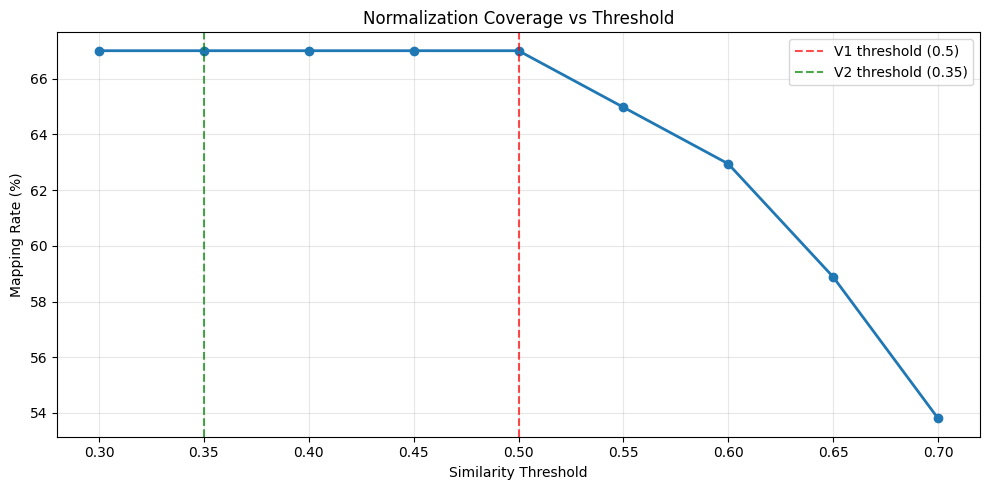


Saved: /content/drive/MyDrive/CS685/linkedin/threshold_analysis.png


In [16]:
# Threshold Analysis
print("="*70)
print("THRESHOLD SENSITIVITY ANALYSIS")
print("="*70)

thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]
threshold_stats = []

for t in thresholds:
    # Count how many would be mapped at this threshold
    mapped_count = ((norm_df_v2['score'] >= t) & (~norm_df_v2['is_nil'])).sum()
    nil_count = ((norm_df_v2['score'] < t) | (norm_df_v2['is_nil'])).sum()

    # Just for semantic matches
    semantic_only = norm_df_v2[norm_df_v2['method'] == 'semantic']
    semantic_mapped = (semantic_only['score'] >= t).sum()

    threshold_stats.append({
        'threshold': t,
        'mapped': mapped_count,
        'nil': nil_count,
        'mapped_pct': mapped_count / len(norm_df_v2) * 100,
        'semantic_captured': semantic_mapped
    })

threshold_df = pd.DataFrame(threshold_stats)
print("\n=== How mapping rate changes with threshold ===")
print(threshold_df.to_string(index=False))

# Plot
plt.figure(figsize=(10, 5))
plt.plot(threshold_df['threshold'], threshold_df['mapped_pct'], marker='o', linewidth=2)
plt.axvline(0.5, color='red', linestyle='--', label='V1 threshold (0.5)', alpha=0.7)
plt.axvline(0.35, color='green', linestyle='--', label='V2 threshold (0.35)', alpha=0.7)
plt.xlabel('Similarity Threshold')
plt.ylabel('Mapping Rate (%)')
plt.title('Normalization Coverage vs Threshold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(BASE / "threshold_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSaved: {BASE / 'threshold_analysis.png'}")

In [17]:
# ESCO Coverage Analysis
print("="*70)
print("ESCO COVERAGE ANALYSIS")
print("="*70)

# Check if common tech skills exist in ESCO
test_skills = ['Node.js', 'JIRA', 'Tableau', 'analytical skills', 'testing',
               'Data Visualization', 'Angular', 'Vue.js', 'React', 'Python',
               'machine learning', 'AWS', 'Docker', 'Kubernetes']

print("\n=== Checking if common skills exist in ESCO ===")
coverage_results = []
for skill in test_skills:
    matches = skill_df[skill_df['variant_lower'].str.contains(skill.lower(), na=False, regex=False)]
    in_esco = len(matches) > 0

    coverage_results.append({
        'skill': skill,
        'in_esco': '✓' if in_esco else '✗'
    })

    if in_esco:
        print(f"\n✓ '{skill}' found in ESCO:")
        print(f"  Example matches: {', '.join(matches['preferred_label'].head(2).tolist())}")
    else:
        print(f"\n✗ '{skill}' NOT in ESCO")

coverage_check_df = pd.DataFrame(coverage_results)
print("\n=== Summary ===")
print(coverage_check_df)

ESCO COVERAGE ANALYSIS

=== Checking if common skills exist in ESCO ===

✗ 'Node.js' NOT in ESCO

✗ 'JIRA' NOT in ESCO

✗ 'Tableau' NOT in ESCO

✗ 'analytical skills' NOT in ESCO

✓ 'testing' found in ESCO:
  Example matches: perform toxicological studies, test materials

✗ 'Data Visualization' NOT in ESCO

✓ 'Angular' found in ESCO:
  Example matches: Angular, Angular

✗ 'Vue.js' NOT in ESCO

✓ 'React' found in ESCO:
  Example matches: respond to changing situations in health care, respond to changing situations in health care

✓ 'Python' found in ESCO:
  Example matches: Python (computer programming), Python (computer programming)

✓ 'machine learning' found in ESCO:
  Example matches: machine learning, machine learning

✓ 'AWS' found in ESCO:
  Example matches: embargo regulations, operate crosscut saw

✗ 'Docker' NOT in ESCO

✗ 'Kubernetes' NOT in ESCO

=== Summary ===
                 skill in_esco
0              Node.js       ✗
1                 JIRA       ✗
2              Tablea

In [18]:
# NIL Analysis
print("="*70)
print("NIL (UNMAPPED) SKILLS ANALYSIS")
print("="*70)

nil_df_v2 = norm_df_v2[norm_df_v2['is_nil']].copy()
nil_counts = nil_df_v2['mention'].value_counts().head(30)

print(f"\nTotal unique NIL skills: {len(nil_df_v2['mention'].unique())}")
print(f"Total NIL mentions: {len(nil_df_v2)}")
print("\n=== Top 30 Unmapped Skills ===")
print(nil_counts)

# Check which exist in ESCO
print("\n=== Checking if top NIL skills exist in ESCO ===")
coverage_analysis = []
for mention in nil_counts.head(15).index:
    in_esco = len(skill_df[skill_df['variant_lower'].str.contains(
        mention.lower(), na=False, regex=False)]) > 0

    # Categorize
    if mention.lower() in ['node.js', 'nodejs', 'jira', 'tableau', 'vue.js', 'react', 'angular']:
        category = 'Modern Tech Tool'
    elif any(word in mention.lower() for word in ['skill', 'ability', 'communication']):
        category = 'Soft Skill'
    elif mention.lower() in ['aws', 'azure', 'gcp', 'cloud']:
        category = 'Cloud Platform'
    else:
        category = 'Other'

    coverage_analysis.append({
        'mention': mention,
        'frequency': nil_counts[mention],
        'in_esco': '✓' if in_esco else '✗',
        'category': category
    })

coverage_df = pd.DataFrame(coverage_analysis)
print("\n", coverage_df.to_string(index=False))

print("\n=== NIL Skills by Category ===")
print(coverage_df.groupby('category').size())

NIL (UNMAPPED) SKILLS ANALYSIS

Total unique NIL skills: 57
Total NIL mentions: 65

=== Top 30 Unmapped Skills ===
mention
Tableau                                  3
Copado                                   2
AWS                                      2
Node.js                                  2
Flask                                    2
Django                                   2
Omnistudio                               2
Appian                                   1
Sync / Async concepts                    1
SQLGood                                  1
PL                                       1
Sun Solaris studio 12                    1
DBXtool                                  1
Oops concept                             1
C++ compiler flags and configurations    1
JIRA.•                                   1
C # development                          1
PowerBI                                  1
Debug BIOS                               1
and                                      1
websocketsExperie

In [19]:
# Manual Evaluation Sample
print("="*70)
print("GENERATING MANUAL EVALUATION SAMPLE")
print("="*70)

def stratified_sample(df, n_per_category):
    """Sample from different score/method categories."""
    samples = []

    # High confidence semantic (score >= 0.7)
    high = df[(df['method'] == 'semantic') & (df['score'] >= 0.7)]
    if len(high) > 0:
        samples.append(high.sample(min(n_per_category, len(high))))

    # Medium confidence semantic (0.5 <= score < 0.7)
    mid = df[(df['method'] == 'semantic') & (df['score'] >= 0.5) & (df['score'] < 0.7)]
    if len(mid) > 0:
        samples.append(mid.sample(min(n_per_category, len(mid))))

    # Low confidence semantic (0.35 <= score < 0.5)
    low = df[(df['method'] == 'semantic') & (df['score'] >= 0.35) & (df['score'] < 0.5)]
    if len(low) > 0:
        samples.append(low.sample(min(n_per_category, len(low))))

    # Substring matches
    substr = df[df['method'] == 'substring_match']
    if len(substr) > 0:
        samples.append(substr.sample(min(n_per_category, len(substr))))

    # NIL
    nil = df[df['is_nil']]
    if len(nil) > 0:
        samples.append(nil.sample(min(n_per_category * 2, len(nil))))

    return pd.concat(samples).sample(frac=1).reset_index(drop=True)

eval_sample = stratified_sample(norm_df_v2, n_per_category=10)
eval_sample = eval_sample[['mention', 'preferred_label', 'matched_variant', 'score', 'method', 'sentence']]

print(f"Generated {len(eval_sample)} samples for manual evaluation")
print("\nFirst 10 samples:")
display(eval_sample.head(10))

# Save for manual review
eval_sample.to_csv(BASE / "normalization_manual_eval_sample.csv", index=False)
print(f"\nSaved: {BASE / 'normalization_manual_eval_sample.csv'}")

GENERATING MANUAL EVALUATION SAMPLE
Generated 50 samples for manual evaluation

First 10 samples:


,mention,preferred_label,matched_variant,score,method,sentence
0,Mobile,mobile marketing,mobile marketing,0.950000,substring_match,"Very high proficiency in Oracle SQL , PL SQL Knowledge of Mobile is desired ."
1,platform debugging skills,ICT debugging tools,ICT debugging tools,0.688033,semantic,"Experience with Debug BIOS , OS , hardware , and platform debugging skills ."
2,executive communication skills,communication,communication,0.950000,substring_match,"He / she should foster innovation , drive critical decisions , hold business..."
3,Building Dashboards,None,None,0.000000,NIL,"Advanced in data manipulation , analysis , and visualization tools ( Tableau..."
4,writing SQLs,None,None,0.000000,NIL,"Advanced in data manipulation , analysis , and visualization tools ( Tableau..."
5,Application Lifecycle Management,manage data,manage data lifecycle,0.677722,semantic,Job Description An advanced software engineer responsible for the entire App...
6,SQL Basic,SQL,SQL,0.796764,semantic,• Implement data validation processes to ensure data quality . Qualification...
7,.NET Core,Visual Basic,Visual Studio .NET,0.601026,semantic,"• Ability to communicate , written and verbal , with technical and non - tec..."
8,Snowflake AWSPython programming,None,None,0.000000,NIL,HiI have onsite role local will be preference Snowflake Developer ( AWS)loca...
9,Automated,automated analysers in the medical laboratory,automated analysers,0.950000,substring_match,"• Ability to communicate , written and verbal , with technical and non - tec..."



Saved: /content/drive/MyDrive/CS685/linkedin/normalization_manual_eval_sample.csv


In [20]:
print("="*70)
print("SAVING RESULTS")
print("="*70)

# Save V1 and V2 results
norm_df_v1.to_csv(BASE / "skill_normalization_results_v1.csv", index=False)
print(f"✓ Saved: skill_normalization_results_v1.csv")

norm_df_v2.to_csv(BASE / "skill_normalization_results_v2.csv", index=False)
print(f"✓ Saved: skill_normalization_results_v2.csv")

# Save comparison
comparison_df.to_csv(BASE / "normalization_version_comparison.csv", index=False)
print(f"✓ Saved: normalization_version_comparison.csv")

# Save newly mapped
if len(newly_mapped) > 0:
    newly_mapped.to_csv(BASE / "normalization_newly_mapped_v2.csv", index=False)
    print(f"✓ Saved: normalization_newly_mapped_v2.csv")

# Save coverage analysis
coverage_df.to_csv(BASE / "normalization_coverage_analysis.csv", index=False)
print(f"✓ Saved: normalization_coverage_analysis.csv")

# Save combined stats
combined_stats = {
    'v1': stats_v1,
    'v2': stats_v2,
    'improvement_pct_points': float(improvement),
    'newly_mapped_count': int(len(newly_mapped))
}

with open(BASE / "normalization_stats_comparison.json", 'w') as f:
    json.dump(combined_stats, f, indent=2)
print(f"✓ Saved: normalization_stats_comparison.json")

print("\n All results saved!")

SAVING RESULTS
✓ Saved: skill_normalization_results_v1.csv
✓ Saved: skill_normalization_results_v2.csv
✓ Saved: normalization_version_comparison.csv
✓ Saved: normalization_newly_mapped_v2.csv
✓ Saved: normalization_coverage_analysis.csv
✓ Saved: normalization_stats_comparison.json

 All results saved!
